<a href="https://colab.research.google.com/github/dhrithisv06-tech/CapstoneProject-Crop-Care-AI/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
nvidia-smi

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files

files.upload()

Saving diseased leaf.jpg to diseased leaf.jpg


{'diseased leaf.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x18\x11\x12\x15\x12\x0f\x18\x15\x14\x15\x1b\x1a\x18\x1d$<\'$!!$J58,<XM\\[VMUSam\x8bvag\x83hSUy\xa5z\x83\x8f\x94\x9c\x9d\x9c^t\xab\xb7\xa9\x97\xb5\x8b\x99\x9c\x95\xff\xdb\x00C\x01\x1a\x1b\x1b$ $G\'\'G\x95dUd\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\xff\xc2\x00\x11\x08\x04e\x05\xdc\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1a\x00\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x00\x04\x05\x06\xff\xc4\x00\x18\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xda\x00\x0c\x03\x01\x00\x02\x10\x03\x10\x00\x00\x01\xea\xa2\xbe@\x86\x1dXP8\xd0\xe7\xe9\xe3\xce\xbc\x95*\xcb\x10M\xb66\xd8\xdbcm\x8d\xb66\xd8\xdd\xbc}yu\xb4\xdb\x15\x91\xf5Q\x94\xee1\xcd\\~g\xb

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 145MB/s]



In [ ]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
!pip install torch torchvision scikit-learn matplotlib pillow

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
!ls -R | head -100

.:
diseased leaf.jpg
plantdisease.zip
plantvillage
PlantVillage
sample_data

./plantvillage:
PlantVillage

./plantvillage/PlantVillage:
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus

./plantvillage/PlantVillage/Pepper__bell___Bacterial_spot:
0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG
006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG
00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG
01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Spot 3262.JPG
0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B.Spot 9169.JPG
018e494e-d2eb-468b-9d02-40219d9f4921___JR_B.Spot 9045.JPG
01940b6d-7dea-4889-a7b8-a35f4e9bba34___NREC_B.Spot 9120.JPG
01dfb88b-cd5a-420c-b163-51f5fe07

In [ ]:
!find /content -type d | grep -i PlantVillage

/content/plantvillage
/content/plantvillage/PlantVillage
/content/plantvillage/PlantVillage/Tomato__Target_Spot
/content/plantvillage/PlantVillage/Tomato_healthy
/content/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/content/plantvillage/PlantVillage/Pepper__bell___healthy
/content/plantvillage/PlantVillage/Potato___Early_blight
/content/plantvillage/PlantVillage/Tomato_Bacterial_spot
/content/plantvillage/PlantVillage/Tomato_Leaf_Mold
/content/plantvillage/PlantVillage/Tomato__Tomato_mosaic_virus
/content/plantvillage/PlantVillage/Tomato_Septoria_leaf_spot
/content/plantvillage/PlantVillage/Potato___healthy
/content/plantvillage/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/content/plantvillage/PlantVillage/Tomato_Early_blight
/content/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot
/content/plantvillage/PlantVillage/Tomato_Late_blight
/content/plantvillage/PlantVillage/Potato___Late_blight
/content/PlantVillage
/content/PlantVillage/Tomato__Targ

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    "/content/PlantVillage",
    transform=transform
)

In [ ]:
print("Total Images:", len(dataset))

Total Images: 20638


In [ ]:
print(dataset.classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
from torch.utils.data import random_split

In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [ ]:
print(len(dataset.classes))
print(dataset.classes)

15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class PlantModel(nn.Module):
    def __init__(self, num_classes=15):
        super(PlantModel, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # 👇 HERE is where you put them
        self.fc1 = nn.LazyLinear(128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
import torch
import torch.nn as nn

num_classes = len(dataset.classes)

class PlantCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = PlantCNN().to(device)

print(model)

PlantCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=15, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 5

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss
        / len(train_loader)
    )

    train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}"
    )

Epoch 1/5, Loss: 1.2382
Epoch 2/5, Loss: 0.5457
Epoch 3/5, Loss: 0.3379
Epoch 4/5, Loss: 0.2483
Epoch 5/5, Loss: 0.1560


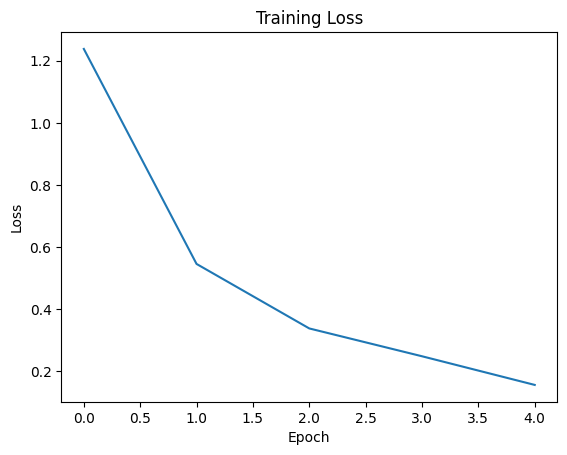

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "plant_model.pth"
)

print("Model Saved!")

Model Saved!


In [ ]:
!ls

'diseased leaf.jpg'   plant_model.pth   PlantVillage
 plantdisease.zip     plantvillage      sample_data


In [ ]:
model = PlantCNN().to(device)

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted==labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy = {accuracy:.2f}%"
)

Accuracy = 7.78%


In [ ]:
import torch
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:   # or val_loader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
class_names = dataset.classes   # if using ImageFolder

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.05      0.01      0.01       142
                     Pepper__bell___healthy       0.00      0.00      0.00       230
                      Potato___Early_blight       0.00      0.00      0.00       159
                       Potato___Late_blight       0.00      0.00      0.00       154
                           Potato___healthy       0.00      0.00      0.00        23
                      Tomato_Bacterial_spot       0.00      0.00      0.00       326
                        Tomato_Early_blight       0.00      0.00      0.00       163
                         Tomato_Late_blight       0.00      0.00      0.00       257
                           Tomato_Leaf_Mold       0.00      0.00      0.00       143
                  Tomato_Septoria_leaf_spot       0.00      0.00      0.00       275
Tomato_Spider_mites_Two_spotted_spider_mite       0.08      1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(np.unique(y_pred))

[ 0  5  8 10]


In [ ]:
from collections import Counter
print(Counter(y_true))

Counter({np.int64(12): 461, np.int64(5): 326, np.int64(9): 275, np.int64(7): 257, np.int64(14): 250, np.int64(10): 241, np.int64(1): 230, np.int64(11): 216, np.int64(6): 163, np.int64(2): 159, np.int64(3): 154, np.int64(8): 143, np.int64(0): 142, np.int64(13): 57, np.int64(4): 23})


In [ ]:
from collections import Counter

print("True labels:", Counter(y_true))
print("Pred labels:", Counter(y_pred))

True labels: Counter({np.int64(12): 461, np.int64(5): 326, np.int64(9): 275, np.int64(7): 257, np.int64(14): 250, np.int64(10): 241, np.int64(1): 230, np.int64(11): 216, np.int64(6): 163, np.int64(2): 159, np.int64(3): 154, np.int64(8): 143, np.int64(0): 142, np.int64(13): 57, np.int64(4): 23})
Pred labels: Counter({np.int64(10): 3056, np.int64(0): 19, np.int64(5): 12, np.int64(8): 10})


In [ ]:
print("Total classes in dataset:", len(set(y_true)))
print("Predicted classes:", len(set(y_pred)))

Total classes in dataset: 15
Predicted classes: 4


In [ ]:
epochs = 15 or 20

In [ ]:
len(set(y_true)), len(set(y_pred))

(15, 4)

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 15)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
epochs = 15

In [ ]:
epochs = 15
lr = 0.0001

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    "/content/plantvillage/PlantVillage",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
import os

print(os.listdir("/content/plantvillage/PlantVillage"))

['Tomato__Target_Spot', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Tomato_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot', 'Potato___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Late_blight', 'Potato___Late_blight']


In [ ]:
import torch

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/15, Loss: 0.2462
Epoch 2/15, Loss: 0.0401
Epoch 3/15, Loss: 0.0258
Epoch 4/15, Loss: 0.0250
Epoch 5/15, Loss: 0.0253
Epoch 6/15, Loss: 0.0160
Epoch 7/15, Loss: 0.0189
Epoch 8/15, Loss: 0.0184
Epoch 9/15, Loss: 0.0102
Epoch 10/15, Loss: 0.0142
Epoch 11/15, Loss: 0.0186
Epoch 12/15, Loss: 0.0114
Epoch 13/15, Loss: 0.0097
Epoch 14/15, Loss: 0.0140
Epoch 15/15, Loss: 0.0120


In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.99      1.00       142
                     Pepper__bell___healthy       1.00      1.00      1.00       230
                      Potato___Early_blight       1.00      0.96      0.98       159
                       Potato___Late_blight       1.00      0.98      0.99       154
                           Potato___healthy       1.00      1.00      1.00        23
                      Tomato_Bacterial_spot       0.99      1.00      1.00       326
                        Tomato_Early_blight       1.00      0.97      0.98       163
                         Tomato_Late_blight       0.99      0.99      0.99       257
                           Tomato_Leaf_Mold       1.00      0.95      0.97       143
                  Tomato_Septoria_leaf_spot       0.97      1.00      0.98       275
Tomato_Spider_mites_Two_spotted_spider_mite       0.98      1.00

In [ ]:
print("Pred classes:", len(set(y_pred)))
print("True classes:", len(set(y_true)))

Pred classes: 15
True classes: 15


In [ ]:
from collections import Counter

print("True:", Counter(y_true))
print("Pred:", Counter(y_pred))

True: Counter({np.int64(12): 461, np.int64(5): 326, np.int64(9): 275, np.int64(7): 257, np.int64(14): 250, np.int64(10): 241, np.int64(1): 230, np.int64(11): 216, np.int64(6): 163, np.int64(2): 159, np.int64(3): 154, np.int64(8): 143, np.int64(0): 142, np.int64(13): 57, np.int64(4): 23})
Pred: Counter({np.int64(12): 465, np.int64(5): 329, np.int64(9): 283, np.int64(7): 257, np.int64(14): 252, np.int64(10): 247, np.int64(1): 231, np.int64(11): 212, np.int64(6): 158, np.int64(2): 152, np.int64(3): 151, np.int64(0): 141, np.int64(8): 136, np.int64(13): 60, np.int64(4): 23})


In [ ]:
correct = sum(np.array(y_true) == np.array(y_pred))
print("Accuracy:", correct / len(y_true))

Accuracy: 0.9903132063287052


In [ ]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

20638
3097


In [ ]:
print(test_loader)

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    "/content/plantvillage/PlantVillage",
    transform=transform
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(dataset.classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0141
Epoch 2, Loss: 0.0106
Epoch 3, Loss: 0.0103
Epoch 4, Loss: 0.0084
Epoch 5, Loss: 0.0084
Epoch 6, Loss: 0.0047
Epoch 7, Loss: 0.0101
Epoch 8, Loss: 0.0019
Epoch 9, Loss: 0.0077
Epoch 10, Loss: 0.0137
Epoch 11, Loss: 0.0092
Epoch 12, Loss: 0.0083
Epoch 13, Loss: 0.0072
Epoch 14, Loss: 0.0053
Epoch 15, Loss: 0.0026


In [ ]:
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       192
           1       1.00      1.00      1.00       310
           2       0.99      1.00      0.99       197
           3       0.99      1.00      0.99       206
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00       427
           6       1.00      0.97      0.99       194
           7       0.99      0.99      0.99       383
           8       1.00      1.00      1.00       201
           9       1.00      0.99      1.00       364
          10       1.00      1.00      1.00       328
          11       1.00      1.00      1.00       283
          12       1.00      1.00      1.00       633
          13       1.00      1.00      1.00        68
          14       1.00      1.00      1.00       312

    accuracy                           1.00      4128
   macro avg       1.00      1.00      1.00      4128
weighted avg       1.00   

In [ ]:
import numpy as np

correct = sum(np.array(y_true) == np.array(y_pred))
accuracy = correct / len(y_true)

print("Accuracy:", accuracy)

Accuracy: 0.997577519379845


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       192
           1       1.00      1.00      1.00       310
           2       0.99      1.00      0.99       197
           3       0.99      1.00      0.99       206
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00       427
           6       1.00      0.97      0.99       194
           7       0.99      0.99      0.99       383
           8       1.00      1.00      1.00       201
           9       1.00      0.99      1.00       364
          10       1.00      1.00      1.00       328
          11       1.00      1.00      1.00       283
          12       1.00      1.00      1.00       633
          13       1.00      1.00      1.00        68
          14       1.00      1.00      1.00       312

    accuracy                           1.00      4128
   macro avg       1.00      1.00      1.00      4128
weighted avg       1.00   

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[192   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 310   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 197   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 206   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 427   0   0   0   0   0   0   0   0   0]
 [  1   0   0   0   0   0 189   2   1   0   0   1   0   0   0]
 [  0   0   0   3   0   0   0 380   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 201   0   0   0   0   0   0]
 [  0   0   2   0   0   0   0   0   0 362   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 328   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 283   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 633   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  68   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 312]]


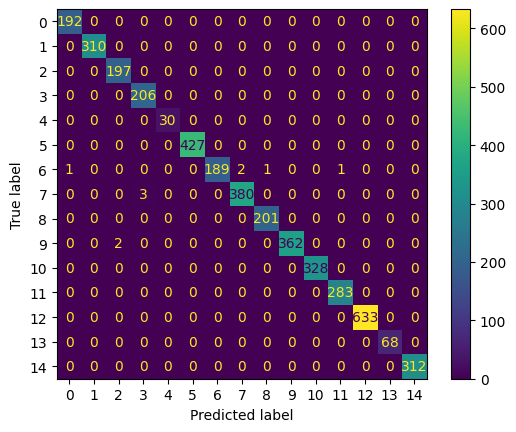

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
from google.colab import files
files.upload()

Saving diseased leaf.jpg to diseased leaf (1).jpg


{'diseased leaf (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x18\x11\x12\x15\x12\x0f\x18\x15\x14\x15\x1b\x1a\x18\x1d$<\'$!!$J58,<XM\\[VMUSam\x8bvag\x83hSUy\xa5z\x83\x8f\x94\x9c\x9d\x9c^t\xab\xb7\xa9\x97\xb5\x8b\x99\x9c\x95\xff\xdb\x00C\x01\x1a\x1b\x1b$ $G\'\'G\x95dUd\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\x95\xff\xc2\x00\x11\x08\x04e\x05\xdc\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1a\x00\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x00\x04\x05\x06\xff\xc4\x00\x18\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xda\x00\x0c\x03\x01\x00\x02\x10\x03\x10\x00\x00\x01\xea\xa2\xbe@\x86\x1dXP8\xd0\xe7\xe9\xe3\xce\xbc\x95*\xcb\x10M\xb66\xd8\xdbcm\x8d\xb66\xd8\xdd\xbc}yu\xb4\xdb\x15\x91\xf5Q\x94\xee1\xcd\\~

In [ ]:
from PIL import Image

In [ ]:
image = Image.open("diseased leaf.jpg")

In [ ]:
from PIL import Image
import torch

image = Image.open("diseased leaf.jpg").convert("RGB")

image = transform(image)
image = image.unsqueeze(0)
image = image.to(device)

model.eval()

with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1)

pred_idx = prediction.item()

print("Class Index:", pred_idx)
print("Disease:", dataset.classes[pred_idx])

Class Index: 0
Disease: Pepper__bell___Bacterial_spot


In [ ]:
import torch

torch.save(model.state_dict(), "model.pth")

In [ ]:
from google.colab import files
files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>